# MachSense — 01. Paderborn End-to-End

Primary end-to-end workflow for **MachSense** using the **Paderborn University Bearing Dataset** (17 run-to-failure lifetime trajectories).

The pipeline encompasses:
1. Environment and disk validation
2. Automated retrieval of Paderborn author release
3. Multimodal alignment & feature extraction (20 spectral bands, 6 operating condition features, 3 temperature channels)
4. Optional raw vibration audit (Zenodo)
5. Strict zero-leakage and schema integrity checks
6. Unified MachSense neural training (GRU encoder + quantile RUL + health regression + reconstruction loss)
7. Out-of-sample held-out bearing trajectory prediction
8. Native-scale RUL verification and checkpoint validation

In [1]:
from pathlib import Path
import sys, shutil, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

from src.data_pipeline import (
    clone_paderborn, file_stats, download_file, safe_extract,
    PADERBORN_B01_URL, require_free_space, create_manifest, build_paderborn_features
)
from src.features import standardize, choose_numeric_features, condition_columns
from src.validation import audit_table, assert_no_leakage, check_checkpoint
from src.experiment import train_machsense, load_checkpoint, predict_series

# Pipeline configuration
DOWNLOAD_RAW_B01 = True   # Set True to audit official raw B01 vibration files (~1 GB)
EPOCHS = 15
WINDOW = 32
BATCH_SIZE = 64


Project root: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4


## 1. Environment and disk check
Verify system environment and ensure sufficient local disk space is available.

In [2]:
import platform

print("Python version:", platform.python_version())
require_free_space(ROOT, 2.0)
print(f"Available disk space: {shutil.disk_usage(ROOT).free / 1e9:.2f} GB")


Python version: 3.11.9
Available disk space: 11.93 GB


## 2. Download Paderborn public feature release
Clone or verify the public repository containing lifetime spectral FFT, operating conditions, and temperature data.

In [3]:
RAW = ROOT / "data" / "raw"
DL = ROOT / "data" / "downloads"
PROC = ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
DL.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

pader_root = RAW / "paderborn_author"
clone_paderborn(pader_root)
print("Paderborn repository stats:", file_stats(pader_root))


Paderborn repository stats: {'root': 'C:\\Users\\rahul\\Downloads\\MachSense_Model_v4\\MachSense_Model_v4\\data\\raw\\paderborn_author', 'files': 105, 'bytes': 323484655, 'gb': 0.323484655}


## 3. Prepare the Paderborn feature table
Extract and align the 17 bearings across FFT spectral representations, operating conditions, and temperature sensors into a standardized parquet format.

In [4]:
pader_out = PROC / "paderborn_features.parquet"
pader_df = build_paderborn_features(pader_root, pader_out)
print("Paderborn feature table shape:", pader_df.shape)
print(f"Number of independent bearings: {pader_df['bearing_id'].nunique()}")
pader_df.head()


[skip] Using existing features from paderborn_features.parquet
Paderborn feature table shape: (95660, 34)
Number of independent bearings: 17


,fft_band_00,fft_band_01,fft_band_02,fft_band_03,fft_band_04,fft_band_05,fft_band_06,fft_band_07,fft_band_08,fft_band_09,...,setSpeed / rpm,meanAbs_speed / rpm,temp_1,temp_2,temp_3,bearing_id,time_idx,rul_raw,speed,load
0,68.021339,10.303662,8.102518,2.066976,3.779432,2.918016,1.367837,0.943287,0.785402,1.024274,...,750.0,753.116231,21.437794,21.336023,21.475223,B01,0,376.0,750.0,0.0
1,69.069618,9.180381,7.672934,2.135686,3.462366,3.204674,1.246233,1.093875,0.816118,1.043270,...,750.0,753.117573,21.675971,21.563905,21.472080,B01,1,375.0,750.0,0.0
2,72.505219,9.907602,7.488900,1.969486,3.755203,3.139289,1.205876,1.028404,0.789402,0.976114,...,750.0,753.091176,21.900365,21.790959,21.450842,B01,2,374.0,750.0,0.0
3,68.892395,10.384083,7.543975,2.053588,3.905467,3.230982,1.353868,1.005268,0.821938,0.993554,...,750.0,753.082943,22.126000,22.028608,21.442562,B01,3,373.0,750.0,0.0
4,67.856056,10.731463,7.037188,2.075168,3.540414,3.371603,1.350968,0.986977,0.773510,1.009311,...,750.0,753.141421,22.354794,22.275628,21.434282,B01,4,372.0,750.0,0.0


## 4. Optional official raw B01 audit
Optionally download and inspect the raw high-frequency B01 bearing sensor recording.

In [5]:
if DOWNLOAD_RAW_B01:
    require_free_space(ROOT, 3.0)
    z = DL / "Paderborn_B01.zip"
    download_file(PADERBORN_B01_URL, z)
    raw_b01 = safe_extract(z, RAW / "paderborn_raw_B01")
    print("Raw B01 directory stats:", file_stats(raw_b01))
else:
    print("Skipping raw B01 download (set DOWNLOAD_RAW_B01 = True to enable)")


[skip] Paderborn_B01.zip (0.97 GB)
Raw B01 directory stats: {'root': 'C:\\Users\\rahul\\Downloads\\MachSense_Model_v4\\MachSense_Model_v4\\data\\raw\\paderborn_raw_B01', 'files': 381, 'bytes': 1091469305, 'gb': 1.091469305}


## 5. Validation and leakage checks
Run data quality audit and strict leakage tests to ensure target variables, IDs, and temporal indices are quarantined from model inputs.

In [6]:
pader_df = standardize(pader_df)
audit_info = audit_table(pader_df, "paderborn")
print("Dataset audit:", audit_info)

features = choose_numeric_features(pader_df)
conditions = condition_columns(pader_df, "paderborn")
assert_no_leakage(features)

print(f"Model input features ({len(features)}):", features)
print(f"Operating condition variables ({len(conditions)}):", conditions)


Dataset audit: {'name': 'paderborn', 'rows': 95660, 'runs': 17, 'columns': 34, 'missing_values': 0}
Model input features (29): ['fft_band_00', 'fft_band_01', 'fft_band_02', 'fft_band_03', 'fft_band_04', 'fft_band_05', 'fft_band_06', 'fft_band_07', 'fft_band_08', 'fft_band_09', 'fft_band_10', 'fft_band_11', 'fft_band_12', 'fft_band_13', 'fft_band_14', 'fft_band_15', 'fft_band_16', 'fft_band_17', 'fft_band_18', 'fft_band_19', 'setDynLoad / N', 'peak_dynLoad / N', 'setStatLoad / N', 'meanAbs_statLoad / N', 'setSpeed / rpm', 'meanAbs_speed / rpm', 'temp_1', 'temp_2', 'temp_3']
Operating condition variables (2): ['speed', 'load']


## 6. Train MachSense
Train the multi-task MachSense neural architecture with combined loss (quantile pinball RUL loss, health regression, and feature reconstruction error).

In [7]:
checkpoint_path, metrics, sample_path = train_machsense(
    pader_df, "paderborn", epochs=EPOCHS, batch_size=BATCH_SIZE, window=WINDOW
)
print("Checkpoint created at:", checkpoint_path)
print("Held-out validation bearing:", metrics["validation_bearing"])
print("Best validation loss:", f"{metrics['best_val_loss']:.4f}")
print("Sample CSV for dashboard:", sample_path)


[paderborn] epoch=001 train=0.0854 val=0.1470 normalized_RMSE=0.2005
[paderborn] epoch=005 train=0.0231 val=0.1861 normalized_RMSE=0.2202
[paderborn] epoch=010 train=0.0173 val=0.1430 normalized_RMSE=0.1521
[paderborn] epoch=015 train=0.0150 val=0.2076 normalized_RMSE=0.2558
Checkpoint created at: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4\artifacts\checkpoints\machsense_paderborn.pt
Held-out validation bearing: B17
Best validation loss: 0.1430
Sample CSV for dashboard: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4\artifacts\check_samples\paderborn_validation_input.csv


## 7. Held-out trajectory
Generate health, quantile RUL, and anomaly trajectory for the held-out bearing.

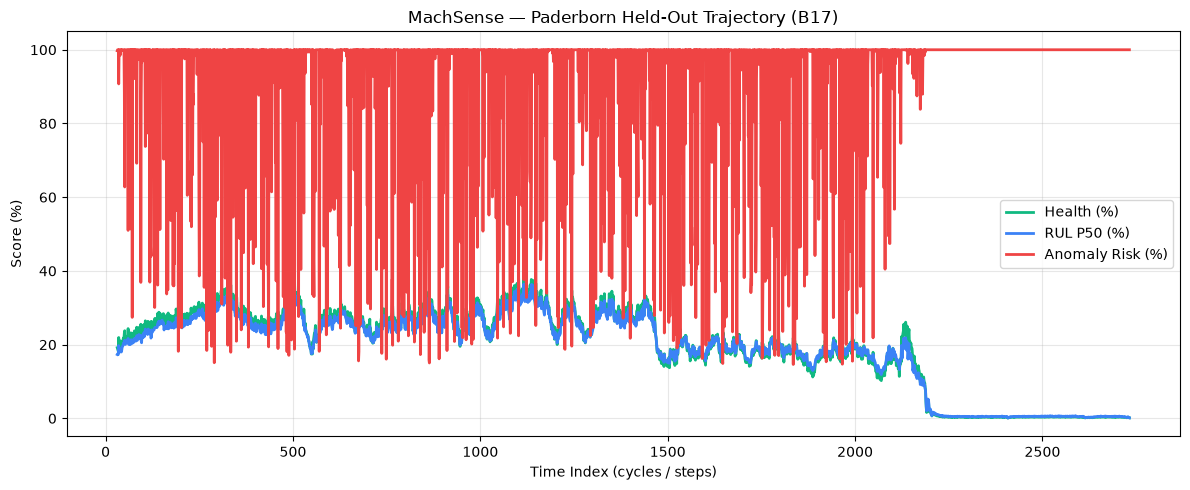

Latest prediction rows:


,index,bearing_id,time_idx,health,rul_p10,rul_p50,rul_p90,anomaly,stage,action,rul_p50_native
2692,2723,B17,2723,0.242344,0.068022,0.351071,1.153864,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,79.222664
2693,2724,B17,2724,0.216028,0.058597,0.308842,1.036574,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,69.693390
2694,2725,B17,2725,0.154959,0.036956,0.208184,0.739421,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,46.978733
2695,2726,B17,2726,0.195428,0.051681,0.275193,0.936172,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,62.100124
2696,2727,B17,2727,0.188209,0.048586,0.260057,0.893649,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,58.684361
2697,2728,B17,2728,0.331529,0.093810,0.419771,1.312839,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,94.725578
2698,2729,B17,2729,0.314434,0.081893,0.370928,1.168013,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,83.703590
2699,2730,B17,2730,0.223671,0.055464,0.259481,0.871058,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,58.554531
2700,2731,B17,2731,0.163151,0.032387,0.163507,0.594928,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,36.896965
2701,2732,B17,2732,0.140634,0.027106,0.141335,0.523394,100.0,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,31.893642


In [8]:
_, ckpt = load_checkpoint("paderborn")
held = metrics["validation_bearing"]
val = pader_df[pader_df.bearing_id.astype(str) == str(held)].copy()
pred = predict_series(val, ckpt)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pred.time_idx, pred.health, label="Health (%)", color="#10b981", linewidth=2)
ax.plot(pred.time_idx, pred.rul_p50, label="RUL P50 (%)", color="#3b82f6", linewidth=2)
ax.plot(pred.time_idx, pred.anomaly, label="Anomaly Risk (%)", color="#ef4444", linewidth=2)
ax.set_xlabel("Time Index (cycles / steps)")
ax.set_ylabel("Score (%)")
ax.set_title(f"MachSense — Paderborn Held-Out Trajectory ({held})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Latest prediction rows:")
display(pred.tail(10))


## 8. Native-unit RUL check
Inspect native domain units for Remaining Useful Life predictions.

In [9]:
native = pred.rul_p50_native
print(f"Native RUL P50 statistics: min={native.min():.1f}, mean={native.mean():.1f}, max={native.max():.1f} steps")


Native RUL P50 statistics: min=21.5, mean=4289.8, max=8461.0 steps


## 9. Final integrity check
Validate model checkpoint structure, feature dimension alignment, and normalization statistics.

In [10]:
check_checkpoint(checkpoint_path)
print("[OK] Paderborn end-to-end pipeline completed successfully!")


[OK] Paderborn end-to-end pipeline completed successfully!
